# 10 feature selection & dimensionality reduction

Two ways to shrink the feature space: **RFE** (supervised, picks useful features) and **PCA** (unsupervised, compresses by variance). Part A does RFE, Part B does PCA, then compares them.

In [1]:
from pathlib import Path

# Works whether the notebook is run from the project root or from the notebooks folder.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)


# Part A — Feature selection (RFE)

## imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE, RFECV
from sklearn.metrics import accuracy_score

## load processed dataset

In [3]:
df = pd.read_csv(DATA_DIR / "processed_carbon_dataset.csv")

feature_cols = [
    "electricity_kwh_per_month", "natural_gas_therms_per_month",
    "fuel_liters_per_month", "car_km_per_month",
    "public_transport_km_per_month", "meat_kg_per_month",
    "energy_per_person", "gas_per_person",
    "fuel_per_person", "car_per_person",
    "transport_ratio", "meat_per_person",
    "food_per_person", "waste_per_person", "log_income"
]

X = df[feature_cols]
y = df["carbon_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


## RFECV — find the optimal number of features

In [4]:
rfecv = RFECV(
    LogisticRegression(max_iter=5000, random_state=42),
    step=1, cv=cv, scoring="accuracy", min_features_to_select=3
)
rfecv.fit(X_train_s, y_train)

selected = [feature_cols[i] for i in range(len(feature_cols)) if rfecv.support_[i]]
dropped  = [f for f in feature_cols if f not in selected]
print("optimal n_features:", rfecv.n_features_)
print("selected:", selected)
print("dropped :", dropped)

optimal n_features: 5
selected: ['electricity_kwh_per_month', 'natural_gas_therms_per_month', 'fuel_liters_per_month', 'car_km_per_month', 'meat_kg_per_month']
dropped : ['public_transport_km_per_month', 'energy_per_person', 'gas_per_person', 'fuel_per_person', 'car_per_person', 'transport_ratio', 'meat_per_person', 'food_per_person', 'waste_per_person', 'log_income']


## accuracy vs number of features

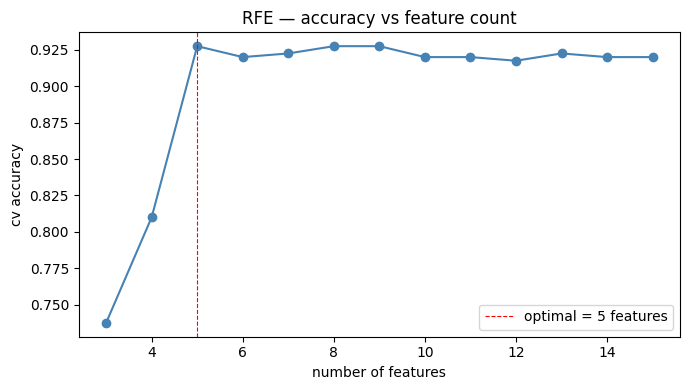

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
n_range = range(rfecv.min_features_to_select, len(feature_cols) + 1)
ax.plot(n_range, rfecv.cv_results_["mean_test_score"], "o-", color="steelblue")
ax.axvline(rfecv.n_features_, color="red", linestyle="--", linewidth=0.8,
           label=f"optimal = {rfecv.n_features_} features")
ax.set_xlabel("number of features"); ax.set_ylabel("cv accuracy")
ax.set_title("RFE — accuracy vs feature count")
ax.legend()
plt.tight_layout()
plt.show()

Accuracy plateaus around 5 features — more add little.

## full vs RFE-selected performance

In [6]:
lr_full = LogisticRegression(max_iter=5000, C=10, random_state=42).fit(X_train_s, y_train)
acc_full = accuracy_score(y_test, lr_full.predict(X_test_s))

X_train_sel = X_train_s[:, rfecv.support_]
X_test_sel  = X_test_s[:, rfecv.support_]
lr_sel = LogisticRegression(max_iter=5000, C=10, random_state=42).fit(X_train_sel, y_train)
acc_sel = accuracy_score(y_test, lr_sel.predict(X_test_sel))

print(f"full {len(feature_cols)}-feature LR : test = {acc_full:.4f}")
print(f"RFE {rfecv.n_features_}-feature LR  : test = {acc_sel:.4f}")
print(f"-> {len(feature_cols) - rfecv.n_features_} features removed, accuracy change = {acc_sel - acc_full:+.4f}")

full 15-feature LR : test = 0.9500
RFE 5-feature LR  : test = 0.9500
-> 10 features removed, accuracy change = +0.0000


Only **5 features** match the full 15-feature accuracy (0.95). CO2 is driven by a few consumption variables; the rest are redundant for prediction.

## ranking of all features

In [7]:
rank_df = pd.DataFrame({
    "feature": feature_cols,
    "rfe_rank": rfecv.ranking_,
    "selected": rfecv.support_
}).sort_values("rfe_rank")
print(rank_df.to_string(index=False))

                      feature  rfe_rank  selected
    electricity_kwh_per_month         1      True
 natural_gas_therms_per_month         1      True
        fuel_liters_per_month         1      True
             car_km_per_month         1      True
            meat_kg_per_month         1      True
             waste_per_person         2     False
              food_per_person         3     False
public_transport_km_per_month         4     False
              meat_per_person         5     False
                   log_income         6     False
               gas_per_person         7     False
              fuel_per_person         8     False
               car_per_person         9     False
            energy_per_person        10     False
              transport_ratio        11     False


## conclusion

RFE cuts the feature set to 5 with no accuracy loss — CO2 is driven by a few consumption variables, the rest are redundant for prediction.

# Part B — Dimensionality reduction (PCA)

## imports

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFECV
from sklearn.metrics import accuracy_score

## load processed dataset

In [9]:
df = pd.read_csv(DATA_DIR / "processed_carbon_dataset.csv")

feature_cols = [  # same 15-feature set as the modelling notebooks
    "electricity_kwh_per_month", "natural_gas_therms_per_month",
    "fuel_liters_per_month", "car_km_per_month",
    "public_transport_km_per_month", "meat_kg_per_month",
    "energy_per_person", "gas_per_person",
    "fuel_per_person", "car_per_person",
    "transport_ratio", "meat_per_person",
    "food_per_person", "waste_per_person", "log_income"
]

X = df[feature_cols]
y = df["carbon_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("train:", X_train.shape, "test:", X_test.shape)


train: (400, 15) test: (100, 15)


## variance explained (scree plot)

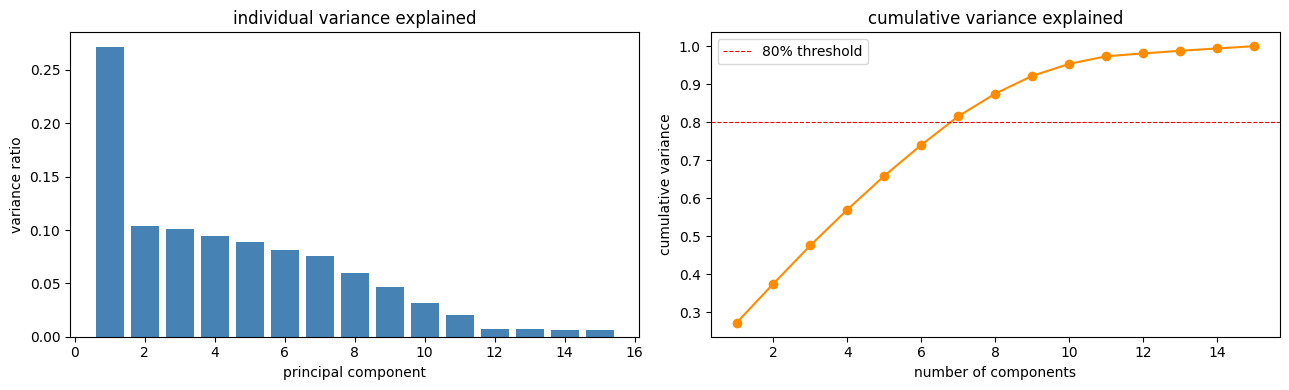

 2 PCs retain 37.5% of variance
 3 PCs retain 47.6% of variance
 5 PCs retain 65.9% of variance
 7 PCs retain 81.6% of variance
10 PCs retain 95.3% of variance


In [10]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)

pca_full = PCA().fit(X_train_s)
explained = pca_full.explained_variance_ratio_
cum = np.cumsum(explained)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(range(1, len(explained) + 1), explained, color="steelblue")
ax[0].set_xlabel("principal component"); ax[0].set_ylabel("variance ratio")
ax[0].set_title("individual variance explained")

ax[1].plot(range(1, len(cum) + 1), cum, "o-", color="darkorange")
ax[1].axhline(0.8, color="red", linestyle="--", linewidth=0.8, label="80% threshold")
ax[1].set_xlabel("number of components"); ax[1].set_ylabel("cumulative variance")
ax[1].set_title("cumulative variance explained")
ax[1].legend()
plt.tight_layout()
plt.show()

for n in [2, 3, 5, 7, 10]:
    print(f"{n:2d} PCs retain {cum[n-1]*100:.1f}% of variance")

## PCA 2D projection

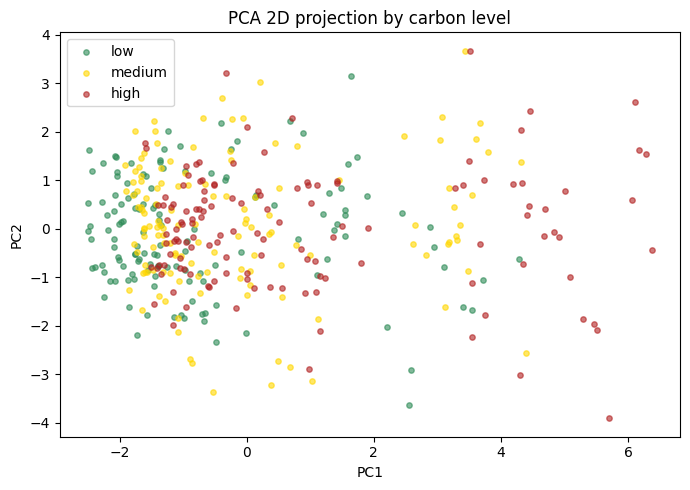

In [11]:
X_pca2 = PCA(n_components=2).fit_transform(X_train_s)

fig, ax = plt.subplots(figsize=(7, 5))
for lvl, col in zip(["low", "medium", "high"], ["seagreen", "gold", "firebrick"]):
    mask = (y_train.values == lvl)
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1], s=15, alpha=0.6, label=lvl, color=col)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("PCA 2D projection by carbon level")
ax.legend()
plt.tight_layout()
plt.show()

Classes overlap heavily in the first two PCs.

## classification on PCA-reduced features

In [12]:
pca_rows = []
for n in [2, 3, 5, 7, 10, 15]:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n)),
        ("model", LogisticRegression(max_iter=5000, C=10, random_state=42))
    ])
    cv_acc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy").mean()
    pipe.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, pipe.predict(X_test))
    pca_rows.append({"n_components": n, "cv_acc": cv_acc, "test_acc": test_acc})

pca_table = pd.DataFrame(pca_rows).round(3)
print(pca_table.to_string(index=False))

 n_components  cv_acc  test_acc
            2   0.425      0.42
            3   0.445      0.43
            5   0.560      0.55
            7   0.845      0.80
           10   0.857      0.85
           15   0.940      0.95


PCA **hurts** accuracy at every component count — even 10 PCs (95% variance) only reach ~0.85. The directions of largest variance are not the ones that separate carbon level.

## reference: full features and RFE

In [13]:
# full 15-feature LR
full_pipe = Pipeline([("scaler", StandardScaler()),
                      ("model", LogisticRegression(max_iter=5000, C=10, random_state=42))])
full_pipe.fit(X_train, y_train)
acc_full = accuracy_score(y_test, full_pipe.predict(X_test))

# RFE-selected subset
rfecv = RFECV(LogisticRegression(max_iter=5000, random_state=42),
              step=1, cv=cv, scoring="accuracy", min_features_to_select=3)
rfecv.fit(X_train_s, y_train)
n_rfe = rfecv.n_features_
X_train_rfe = X_train_s[:, rfecv.support_]
X_test_rfe  = scaler.transform(X_test)[:, rfecv.support_]
lr_rfe = LogisticRegression(max_iter=5000, C=10, random_state=42).fit(X_train_rfe, y_train)
acc_rfe = accuracy_score(y_test, lr_rfe.predict(X_test_rfe))

print(f"full 15 features        : test={acc_full:.3f}")
print(f"RFE {n_rfe} features (supervised): test={acc_rfe:.3f}")

full 15 features        : test=0.950
RFE 5 features (supervised): test=0.950


## final comparison — PCA vs RFE vs full

         method  n_dims  test_acc
   PCA (15 PCs)      15      0.95
  RFE (5 feats)       5      0.95
Full (15 feats)      15      0.95


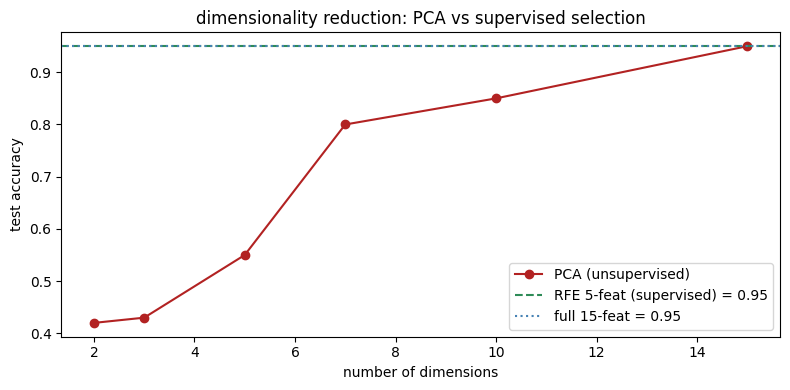

In [14]:
best_pca = pca_table.loc[pca_table["test_acc"].idxmax()]

methods = pd.DataFrame({
    "method": [f"PCA ({int(best_pca['n_components'])} PCs)",
               f"RFE ({n_rfe} feats)",
               "Full (15 feats)"],
    "n_dims": [int(best_pca["n_components"]), n_rfe, 15],
    "test_acc": [best_pca["test_acc"], acc_rfe, acc_full]
})
print(methods.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
# PCA accuracy curve
ax.plot(pca_table["n_components"], pca_table["test_acc"], "o-", color="firebrick", label="PCA (unsupervised)")
ax.axhline(acc_rfe, color="seagreen", linestyle="--", label=f"RFE {n_rfe}-feat (supervised) = {acc_rfe:.2f}")
ax.axhline(acc_full, color="steelblue", linestyle=":", label=f"full 15-feat = {acc_full:.2f}")
ax.set_xlabel("number of dimensions"); ax.set_ylabel("test accuracy")
ax.set_title("dimensionality reduction: PCA vs supervised selection")
ax.legend()
plt.tight_layout()
plt.show()

## conclusion

RFE (supervised) keeps accuracy while cutting features down to 5; PCA (unsupervised) loses accuracy at every component count, even keeping 95% of variance. The directions of largest variance are not the ones that separate carbon level. For this task supervised feature selection is the right tool — PCA is included only as a contrast.